# 手搓简易版 GBDT

## 生成数据

In [1]:
import numpy as np

# 生成带噪声的正弦曲线数据
np.random.seed(42)
X = np.sort(np.random.rand(200, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(200) * 0.2

## 手动实现

In [11]:
n_trees = 9                   # 树的总量
learning_rate = 0.3           # 学习率
trees = []                    # 树的容器
F = np.full_like(y, y.mean()) # 步骤1：用均值初始化

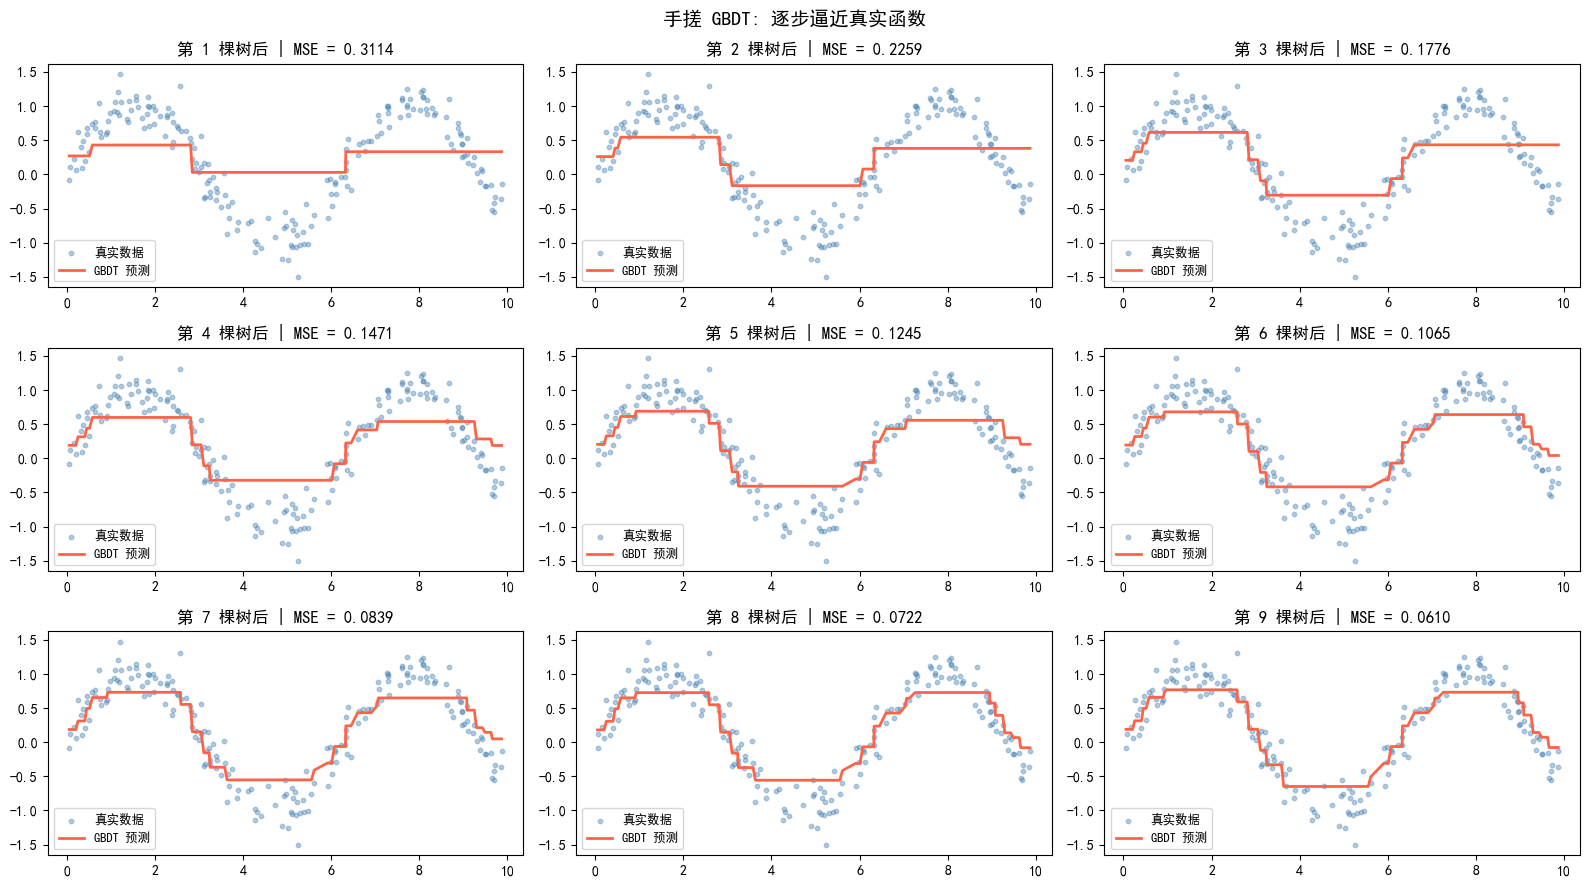

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(3, 3, figsize = (16, 9))

for i in range(n_trees):
  # 计算残差（MSE下的负梯度）
  residual = y - F

  # 用一棵浅树拟合残差
  tree = DecisionTreeRegressor(max_depth= 2)
  tree.fit(X, residual)
  pred = tree.predict(X)
  trees.append(tree)

  # 更新模型
  F += learning_rate * pred

  # 可视化
  mse = np.mean((y - F) ** 2)
  ax = axes[i // 3][i % 3] # 子图行列
  ax.scatter(X, y, s = 10, alpha = 0.4, color = 'steelblue', label = '真实数据')
  ax.plot(X, F, color = 'tomato', linewidth = 2, label = f'GBDT 预测')
  ax.set_title(f'第 {i + 1} 棵树后 | MSE = {mse:.4f}', fontsize = 12)
  ax.legend(fontsize = 9)

plt.suptitle('手搓 GBDT: 逐步逼近真实函数', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

每棵新树都在查漏补缺，模型一轮比一轮精准
- 第 1~3 棵树：红色曲线只是一个粗略的阶梯形，MSE 较大
- 第 4~6 棵树：曲线开始有了正弦的轮廓，MSE 明显下降
- 第 7~9 棵树：曲线越来越贴合蓝色散点，MSE 持续缩小

## 观察残差

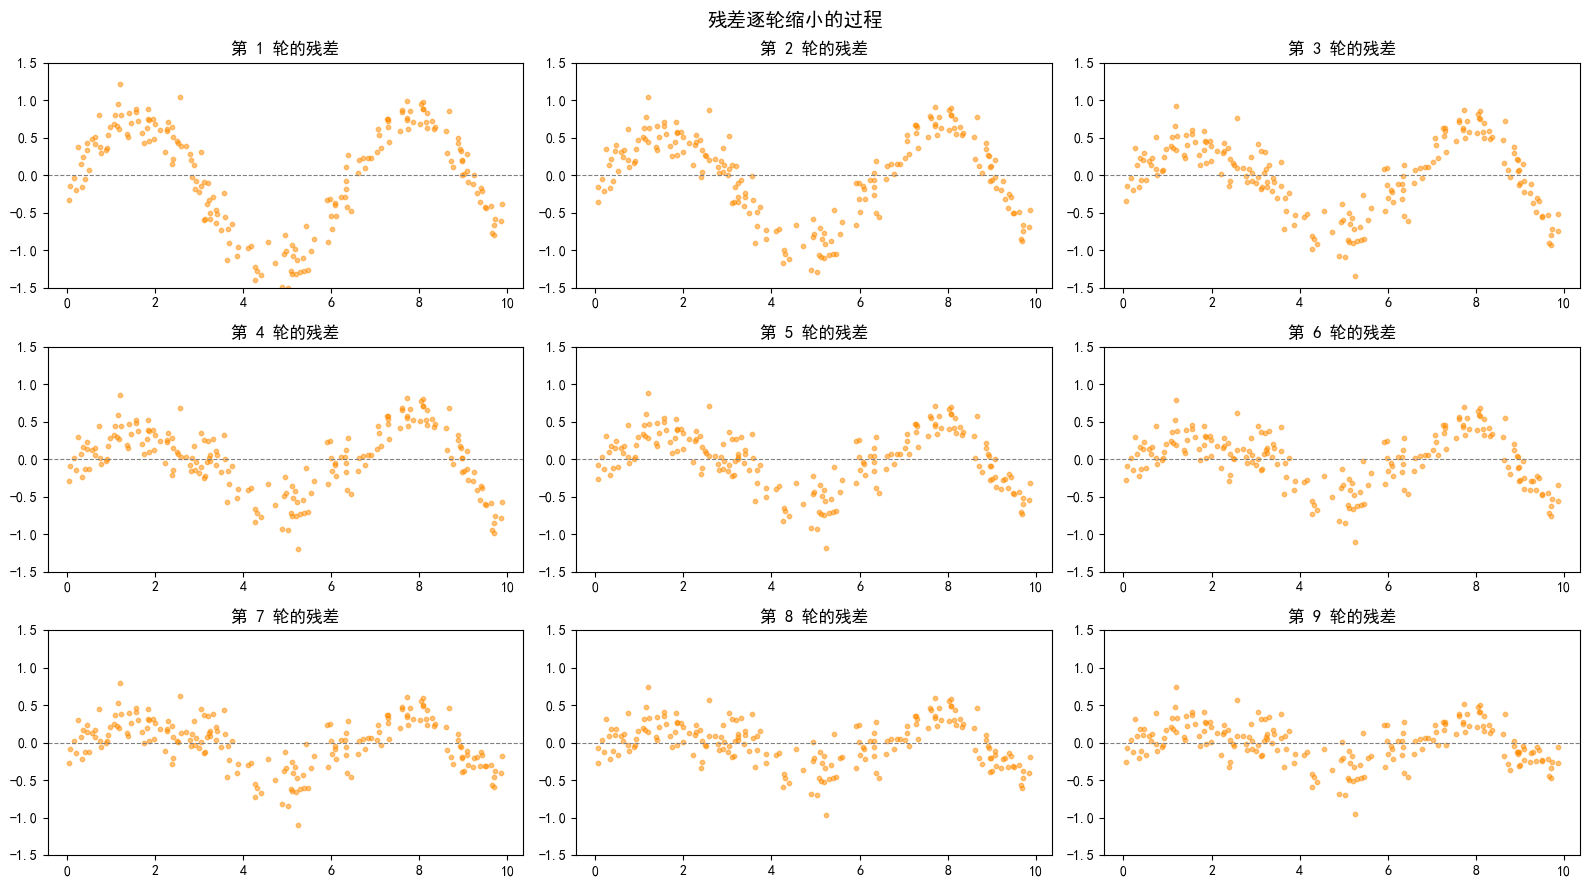

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
F = np.full_like(y, y.mean())

for i in range(n_trees):
    residual = y - F
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residual)
    F += learning_rate * tree.predict(X)

    ax = axes[i // 3][i % 3]
    ax.scatter(X, residual, s=10, alpha=0.5, color='darkorange')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'第 {i + 1} 轮的残差', fontsize=12)
    ax.set_ylim(-1.5, 1.5)

plt.suptitle('残差逐轮缩小的过程', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

橙色散点（残差）逐轮向零线收敛，这正是 Boosting 逐步纠错的过程

# XGBoost 演示

## 准备数据

In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 加载加州房价数据集
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"特征: {feature_names}")

训练集大小: (16512, 8)
测试集大小: (4128, 8)
特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 训练模型
>避坑指南：macOS 用户运行前先 brew install libomp，否则 XGBoost 会报错。

### RandomForest

In [ ]:
import time
from sklearn.ensemble import RandomForestRegressor

# --- 随机森林 ---
rf_start = time.time()         # 记录启动时间
rf = RandomForestRegressor(
  n_estimators= 200,        # 200棵树
  max_depth= 10,            # 最深10层
  random_state= 42,         # 随机种子
  n_jobs= -1                # CPU 并行加速
)

rf.fit(X_train, y_train)
rf_time = time.time() - start
rf_pred = rf.predict(X_test)


### XGBoost

In [19]:
from xgboost import XGBRegressor

# --- XGBoost ---
xgb_start = time.time()
xgb = XGBRegressor(
  n_estimators = 200,     # 200棵树
  max_depth = 5,          # 最深5层
  learning_rate = 0.1,    # 学习率
  subsample = 0.8,        # 每次训练抽选样本比例
  colsample_bytree = 0.8, # 每次训练抽选特征比例
  random_state = 42,      # 随机种子
  n_jobs = -1,            # CPU 并行加速
)
xgb.fit(X_train, y_train)
xgb_time = time.time() - xgb_start
xgb_pred = xgb.predict(X_test)


## 对比结果

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# ---- 结果对比 ----
print("=" * 50)
print(f"{'指标':<15} {'随机森林':>12} {'XGBoost':>12}")
print("=" * 50)
print(f"{'MSE':<15} {mean_squared_error(y_test, rf_pred):>12.4f} "
      f"{mean_squared_error(y_test, xgb_pred):>12.4f}")
print(f"{'R² Score':<15} {r2_score(y_test, rf_pred):>12.4f} "
      f"{r2_score(y_test, xgb_pred):>12.4f}")
print(f"{'训练时间(秒)':<15} {rf_time:>12.2f} {xgb_time:>12.2f}")

指标                      随机森林      XGBoost
MSE                   0.2951       0.2183
R² Score              0.7748       0.8334
训练时间(秒)                 0.83         0.35


## 早停防过拟合

In [21]:
from xgboost import XGBRegressor

xgb_es = XGBRegressor(
  n_estimators=10000,        # 设一个很大的上限
  max_depth=5,
  learning_rate=0.05,       # 用更小的学习率
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42,
  early_stopping_rounds=20  # 20轮不提升就停止
)

xgb_es.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=50                # 每50轮打印一次
)

print(f"\n最佳迭代轮数: {xgb_es.best_iteration}")
print(f"最佳MSE: {mean_squared_error(y_test, xgb_es.predict(X_test)):.4f}")

[0]	validation_0-rmse:1.10982
[50]	validation_0-rmse:0.58158
[100]	validation_0-rmse:0.51513
[150]	validation_0-rmse:0.49332
[200]	validation_0-rmse:0.48048
[250]	validation_0-rmse:0.47419
[300]	validation_0-rmse:0.46723
[350]	validation_0-rmse:0.46332
[400]	validation_0-rmse:0.45993
[450]	validation_0-rmse:0.45621
[500]	validation_0-rmse:0.45452
[550]	validation_0-rmse:0.45219
[600]	validation_0-rmse:0.45087
[650]	validation_0-rmse:0.44945
[700]	validation_0-rmse:0.44769
[750]	validation_0-rmse:0.44629
[800]	validation_0-rmse:0.44498
[850]	validation_0-rmse:0.44366
[882]	validation_0-rmse:0.44313

最佳迭代轮数: 862
最佳MSE: 0.1963


## 可视化训练过程

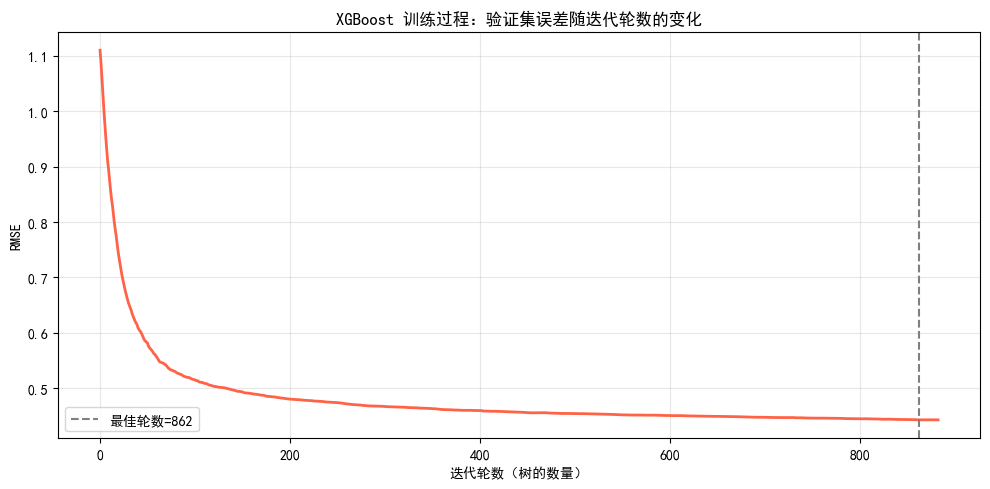

In [22]:
# 获取训练过程中的损失变化
results = xgb_es.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['rmse'], color='tomato', linewidth=2)
plt.xlabel('迭代轮数（树的数量）')
plt.ylabel('RMSE')
plt.title('XGBoost 训练过程：验证集误差随迭代轮数的变化')
plt.axvline(x=xgb_es.best_iteration, color='gray',
            linestyle='--', label=f'最佳轮数={xgb_es.best_iteration}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

会看到验证集的 RMSE 先快速下降，然后趋于平缓，最终可能略微上升（过拟合的信号），Early Stopping 恰好在最低点附近停下来。